Shape: (3724889, 20)

Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'Airport_fee', 'cbd_congestion_fee']

Dtypes:
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag                  str
PULocationID                      int32
DOLocationID                      int32
payment_type                      int64
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement

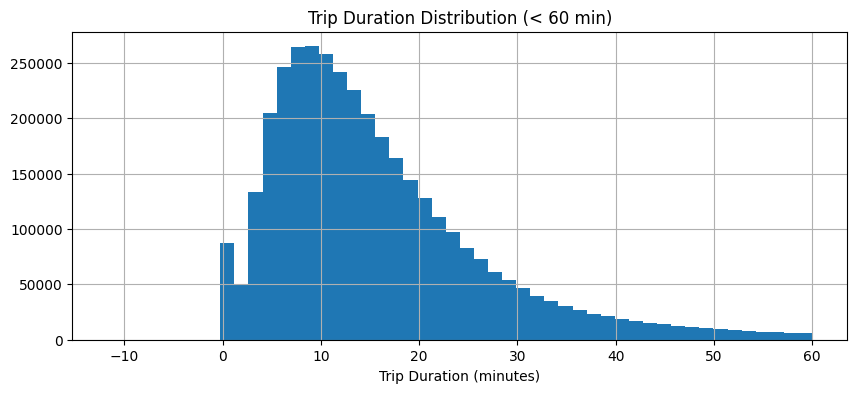

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# load one month of data
df = pd.read_parquet("data/raw/yellow_tripdata_2026-01.parquet")

print(f"Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nDtypes:\n{df.dtypes}")
print(f"\nMissing values:\n{df.isnull().sum()}")

# compute trip duration in minutes
df['duration'] = (df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']).dt.total_seconds() / 60

# distribution check
df['duration'].describe()

# visualize
plt.figure(figsize=(10, 4))
df[df['duration'] < 60]['duration'].hist(bins=50)
plt.xlabel('Trip Duration (minutes)')
plt.title('Trip Duration Distribution (< 60 min)')
plt.show()